### High Frequency Stock Prices
Higher frequency stock data is well modeled by an MA(1) process, so it's a nice application of the models in this chapter.

The DataFrame intraday contains one day's prices (on September 1, 2017) for Sprint stock (ticker symbol "S") sampled at a frequency of one minute. The stock market is open for 6.5 hours (390 minutes), from 9:30am to 4:00pm.

Before you can analyze the time series data, you will have to clean it up a little, which you will do in this and the next two exercises. When you look at the first few rows, you'll notice several things. First, there are no column headers.The data is not time stamped from 9:30 to 4:00, but rather goes from 0 to 390. And you will notice that the first date is the odd-looking "a1504272600". The number after the "a" is Unix time which is the number of seconds since January 1, 1970. This is how this dataset separates each day of intraday data.

If you look at the data types, you'll notice that the DATE column is an object, which here means a string. You will need to change that to numeric before you can clean up some missing data.

The source of the minute data is Google Finance (see here on how the data was downloaded).

The datetime module has already been imported for you.

- Manually change the first date to zero using .iloc[0,0].
- Change the two column headers to 'DATE' and 'CLOSE' by setting intraday.columns equal to a list containing those two strings.
- Use the pandas attribute .dtypes (no parentheses) to see what type of data are in each column.
- Convert the 'DATE' column to numeric using the pandas function to_numeric().
- Make the 'DATE' column the new index of intraday by using the pandas method .set_index(), which will take the string 'DATE' as its argument (not the entire column, just the name of the column).

In [ ]:
# import datetime module
import datetime

# Change the first date to zero
intraday.iloc[0,0] = 0

# Change the column headers to 'DATE' and 'CLOSE'
intraday.columns = ['DATE', 'CLOSE']

# Examine the data types for each column
print(intraday.dtypes)

# Convert DATE column to numeric
intraday['DATE'] = pd.to_numeric(intraday['DATE'])

# Make the `DATE` column the new index
intraday = intraday.set_index('DATE')

#correct output:
DATE      object
CLOSE    float64
dtype: object

Print out the length of intraday using len()

In [ ]:
# Notice that some rows are missing
print("If there were no missing rows, there would be 391 rows of minute data")
print("The actual length of the DataFrame is:", len(intraday))
If there were no missing rows, there would be 391 rows of minute data
The actual length of the DataFrame is: 389

Find the missing rows by making range(391) into a set and then subtracting the set of the intraday index, intraday.index

In [ ]:
# Everything
set_everything = set(range(391))

# The intraday index as a set
set_intraday = set(intraday.index)

# Calculate the difference
set_missing = set_everything - set_intraday

# Print the difference
print("Missing rows: ", set_missing)
Missing rows:  {182, 14}

Fill in the missing rows using the .reindex() method, setting the index equal to the full range(391) and forward filling the missing data by setting the method argument to 'ffill'.

In [ ]:
# Fill in the missing rows
intraday = intraday.reindex(range(391), method='ffill')

- Change the index to times using pandas function date_range(), starting with '2017-09-01 9:30' and ending with '2017-09-01 16:00' and passing the argument freq='1min'.
- Plot the data and include gridlines.

In [ ]:
# From previous step
intraday = intraday.reindex(range(391), method='ffill')

# Change the index to the intraday times
intraday.index = pd.date_range(start='2017-09-01 9:30', end='2017-09-01 16:00', freq='1min')

# Plot the intraday time series
intraday.plot(grid=True)
plt.show()

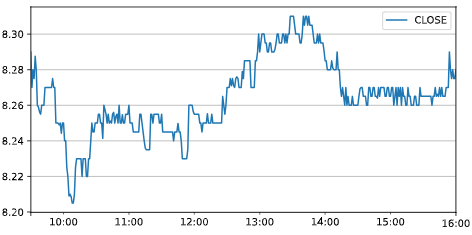

- Import plot_acf and ARIMA modules from statsmodels
- Compute minute-to-minute returns from prices:
    - Compute returns with the .pct_change() method
    - Use the pandas method .dropna() to drop the first row of returns, which is NaN
- Plot the ACF function with lags up to 60 minutes
- Fit the returns data to an MA(1) model and print out the MA(1) parameter

In [ ]:
# Import plot_acf and ARIMA modules from statsmodels
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

# Compute returns from prices and drop the NaN
returns = intraday.dropna()
returns = returns.pct_change()

# Plot ACF of returns with lags up to 60 minutes
plot_acf(returns, lags=60)
plt.show()

# Fit the data to an MA(1) model
mod = ARIMA(returns, order=(0,0,1))
res = mod.fit()
print(res.params[1])
-0.17171619394800597

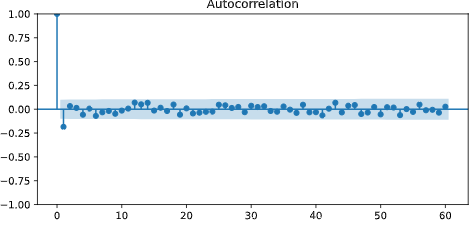

- Import the modules for simulating data and plotting the ACF from statsmodels
- Use a list comprehension to build a list with exponentially decaying MA parameters: 1,0.8,0.8^2,0.8^3,...
- Simulate 5000 observations of the MA(30) model
- Plot the ACF of the simulated series

In [ ]:
# import the modules for simulating data and plotting the ACF
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf

# Build a list MA parameters
ma = [0.8 ** i for i in range(30)]

# Simulate the MA(30) model
ar = np.array([1])
AR_object = ArmaProcess(ar, ma)
simulated_data = AR_object.generate_sample(nsample=5000)

# Plot the ACF
plot_acf(simulated_data, lags=30)
plt.show()

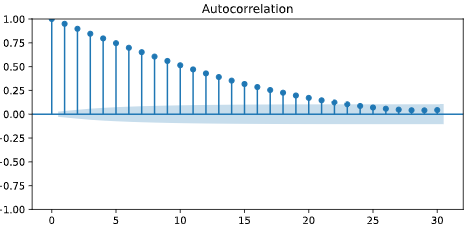

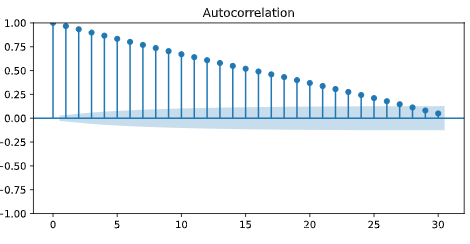

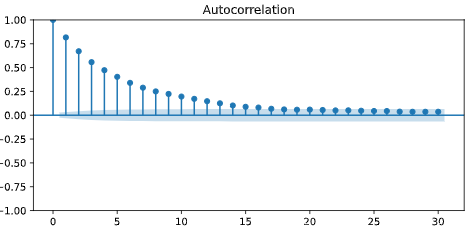

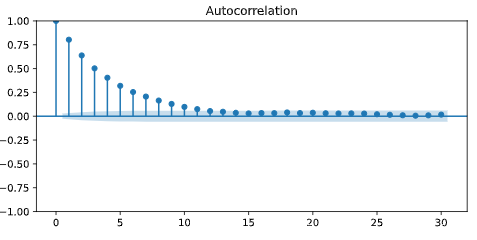